In [2]:
import pandas as pd

In [3]:
# 读取数据
df = pd.read_csv('./data/NMRexp_10to24_1_1004.csv')

# 查看数据前五行
df.head()


,Filename,SMILES,Page_in_file_mol,Page_in_file_para,Location_in_page_mol,Location_in_page_para,NMR_type,NMR_frequency,NMR_solvent,NMR_shift_text,NMR_note,NMR_processed,Atom_number,Atom_number_diff_env,Atom_number_abstract
0,10.1021_acs.orglett.3c00718,[Si](CC)(CC)(CC)/C(F)=C(/Cc1ccc2ccccc2c1)C(=O)OCC,15.0,15,[0.05914522 0.28183596 0.20726104 0.32089846],[0.05459559 0.32343751 0.94227949 0.45234376],13C NMR,101 MHz,CDCl3,"180.0 (d, J = 300.8 Hz), 167.6 (d, J = 22.7 Hz...",NaN,"[(180.0, 'd', 300.8), (167.6, 'd', 22.7), (137...",22,18,17.0
1,10.1021_acs.orglett.3c00718,C(=O)(OC(C)(C)C)/C(Cc1ccccc1)=C(\F)[Si](CC)(CC)CC,15.0,15,[0.05914522 0.48281252 0.18223806 0.52500002],[0.05560662 0.52773439 0.94329046 0.64335941],1H NMR,500 MHz,CDCl3,"7.27-7.24 (m, 2H), 7.19-7.15 (m, 3H), 3.68 (d,...",NaN,"[('m', [], '2H', 7.27, 7.24), ('m', [], '3H', ...",31,7,31.0
2,10.1021_acs.orglett.3c00718,C(=O)(OC(C)(C)C)/C(Cc1ccccc1)=C(\F)[Si](CC)(CC)CC,15.0,15,[0.05914522 0.48281252 0.18223806 0.52500002],[0.05560662 0.52773439 0.94329046 0.64335941],19F NMR,471 MHz,CDCl3,"-95.47 (s, 1F)",NaN,"[(-95.47, 's', None)]",1,1,1.0
3,10.1021_acs.orglett.3c00718,C(=O)(OC(C)(C)C)/C(Cc1ccccc1)=C(\F)[Si](CC)(CC)CC,15.0,15,[0.05914522 0.48281252 0.18223806 0.52500002],[0.05560662 0.52773439 0.94329046 0.64335941],13C NMR,126 MHz,CDCl3,"178.1 (d, J = 297.5 Hz), 166.9 (d, J = 22.3 Hz...",NaN,"[(178.1, 'd', 297.5), (166.9, 'd', 22.3), (139...",20,12,12.0
4,10.1021_acs.orglett.3c00718,[Si](CC)(CC)(CC)/C(F)=C(/CCc1ccccc1)C(=O)OCC,15.0,15,[0.05965074 0.67343756 0.19285387 0.72812506],[0.05459559 0.73203131 0.94430153 0.84765633],1H NMR,400 MHz,CDCl3,"7.28 (t, J = 7.5 Hz, 2H), 7.21-7.17 (m, 3H), 4...",NaN,"[('t', ['7.5Hz'], '2H', 7.28, 7.28), ('m', [],...",29,9,29.0


In [ ]:
# 1. 提取两种NMR（你这两行完全正确）
df_13C = df[df['NMR_type'] == '13C NMR'].copy()
df_1H = df[df['NMR_type'] == '1H NMR'].copy()

# 2. 给列名加后缀，避免合并后混淆
df_13C = df_13C.add_suffix('_13C')
df_1H = df_1H.add_suffix('_1H')

# 3. 按 SMILES 合并（inner join = 只保留同时有两种NMR的分子）
df_common = pd.merge(
    df_13C, df_1H,
    left_on='SMILES_13C',
    right_on='SMILES_1H',
    how='inner'
)

# 4. 新增优先级列：13C和1H溶剂一致的行，优先级=1，否则=0
df_common['solvent_match_priority'] = (
    df_common['NMR_solvent_13C'] == df_common['NMR_solvent_1H']
).astype(int)

# 5. 排序：先按SMILES分组，再按溶剂优先级降序，确保匹配的行排在最前
df_common = df_common.sort_values(
    by=['SMILES_13C', 'solvent_match_priority'],
    ascending=[True, False]
)

# 6. 去重：每个SMILES只保留第一行（自动优先保留溶剂匹配的行）
df_common = df_common.drop_duplicates(subset=['SMILES_13C'], keep='first')

# 7. 清理临时列，统一SMILES列名
df_common['SMILES'] = df_common['SMILES_13C']
df_common.drop(
    ['SMILES_13C', 'SMILES_1H', 'solvent_match_priority'],
    axis=1,
    inplace=True
)


print(df_common[['SMILES', 'NMR_processed_1H', 'NMR_processed_13C']])


                                                    SMILES  \
297388                                   B(/C(/C)=C/C)(O)O   
1801793                            B(/C(=C/CC)c1ccco1)(O)O   
1611420                       B(/C(Cl)=C1\COc2ccccc21)(O)O   
1450421                         B(/C=C/C1=Cc2ccccc2C1)(O)O   
1826064                       B(/C=C/c1cc(OC)cc(OC)c1)(O)O   
...                                                    ...   
1436830  s1c2nc3ccccc3c-2c(-c2cnc3ccccc3c2Sc2ccc(-n3c4c...   
1497088                             s1ccc(SCCCCCCCCCCCC)c1   
1697464  s1cccc1C(CN(CC(=C1CC1)c1ccccc1)S(=O)(=O)c1ccc(...   
379925                         s1cccc1SN(c1ccccc1)c1ccccc1   
638600         s1cnc(C)c1[C@H](CSc1ccccc1)C(=O)c1ccc(C)cc1   

                                          NMR_processed_1H  \
297388   [('qd', "['6.7Hz', '1.5Hz']", '1H', 6.76, 6.76...   
1801793  [('m', [], '1H', 7.42, 7.38), ('m', [], '1H', ...   
1611420  [('s', [], '2H', 5.34, 5.34), ('d', ['8.2Hz'],...   
1450421

In [37]:
# 将 spectra_list 保存在本地# 每个 data point 应该满足：
"""
spectra: {
    'SMILES': df_common['SMILES'],
    '13C_NMR': {
        'frequency': df_common['NMR_13C_frequency'],
        'solvent': df_common['NMR_solvent_13C'],
        'data': df_common['NMR_13C_data']
    },
    '1H_NMR': {
        'frequency': df_common['NMR_1H_frequency'],
        'solvent': df_common['NMR_solvent_1H'],
        'data': df_common['NMR_1H_data']
    }
}
"""

def row_to_spectra(row):
    
    c_raw = row["NMR_processed_13C"]
    h_raw = row["NMR_processed_1H"]

    # --------------------------
    # 处理 13C NMR 数据
    # 格式：(化学位移, None, None) → 只取第一个：化学位移
    # --------------------------
    c_data = [
        {'shift': item[0]}  # 只保留化学位移
        for item in c_raw
    ]

    # --------------------------
    # 处理 1H NMR 数据
    # 格式：('m', [], '1H', 7.42, 7.38)
    # 0: 多重峰类型   1: 耦合参数   2: 氢数   3: 起始位移   4: 结束位移
    # --------------------------
    h_data = [
        {
            'multiplicity': item[0],       # 多重峰 m/s/d/t/q 等
            'coupling': item[1],           # 耦合参数（列表）
            'num_h': item[2],              # 几个氢
            'shift': (item[3], item[4]),        # 位移范围
        }
        for item in h_raw
    ]

    return {
        'SMILES': row['SMILES'],
        '13C_NMR': {
            'frequency': row['NMR_frequency_13C'],
            'solvent': row['NMR_solvent_13C'],
            'data': c_data
        },
        '1H_NMR': {
            'frequency': row['NMR_frequency_1H'],
            'solvent': row['NMR_solvent_1H'],
            'data': h_data
        }
    }
    
df_common['NMR_processed_13C'] = df_common['NMR_processed_13C'].apply(eval)
df_common['NMR_processed_1H'] = df_common['NMR_processed_1H'].apply(eval)

spectra_list = df_common.apply(row_to_spectra, axis=1)
spectra_list = spectra_list.tolist()

print(spectra_list[0].get('1H_NMR'))
print(spectra_list[0].get('13C_NMR'))


{'frequency': '400 MHz', 'solvent': 'CDCl3', 'data': [{'multiplicity': 'qd', 'coupling': "['6.7Hz', '1.5Hz']", 'num_h': '1H', 'shift': (6.76, 6.76)}, {'multiplicity': 'dd', 'coupling': "['6.8Hz', '1.0Hz']", 'num_h': '3H', 'shift': (1.72, 1.72)}, {'multiplicity': 's', 'coupling': [], 'num_h': '3H', 'shift': (1.68, 1.68)}]}
{'frequency': '101 MHz', 'solvent': 'CDCl3', 'data': [{'shift': 143.8}, {'shift': 14.9}, {'shift': 12.8}]}


In [ ]:
# 保存数据

import pickle

with open('./data/NMRexp_Datalist.pkl', 'wb') as f:
    pickle.dump(spectra_list, f)

In [4]:
# 读取数据

import pickle

with open('./data/NMRexp_Datalist.pkl', 'rb') as f:
    spectra_list = pickle.load(f)

In [5]:
print(spectra_list[:3])

[{'SMILES': 'B(/C(/C)=C/C)(O)O', '13C_NMR': {'frequency': '101 MHz', 'solvent': 'CDCl3', 'data': [{'shift': 143.8}, {'shift': 14.9}, {'shift': 12.8}]}, '1H_NMR': {'frequency': '400 MHz', 'solvent': 'CDCl3', 'data': [{'multiplicity': 'qd', 'coupling': "['6.7Hz', '1.5Hz']", 'num_h': '1H', 'shift': (6.76, 6.76)}, {'multiplicity': 'dd', 'coupling': "['6.8Hz', '1.0Hz']", 'num_h': '3H', 'shift': (1.72, 1.72)}, {'multiplicity': 's', 'coupling': [], 'num_h': '3H', 'shift': (1.68, 1.68)}]}}, {'SMILES': 'B(/C(=C/CC)c1ccco1)(O)O', '13C_NMR': {'frequency': '125 MHz', 'solvent': 'CDCl3', 'data': [{'shift': 154.6}, {'shift': 149.7}, {'shift': 140.6}, {'shift': 132.2}, {'shift': 111.3}, {'shift': 109.0}, {'shift': 24.4}, {'shift': 13.6}]}, '1H_NMR': {'frequency': '500 MHz', 'solvent': 'CDCl3', 'data': [{'multiplicity': 'm', 'coupling': [], 'num_h': '1H', 'shift': (7.42, 7.38)}, {'multiplicity': 'm', 'coupling': [], 'num_h': '1H', 'shift': (6.64, 6.57)}, {'multiplicity': 'm', 'coupling': [], 'num_h': 

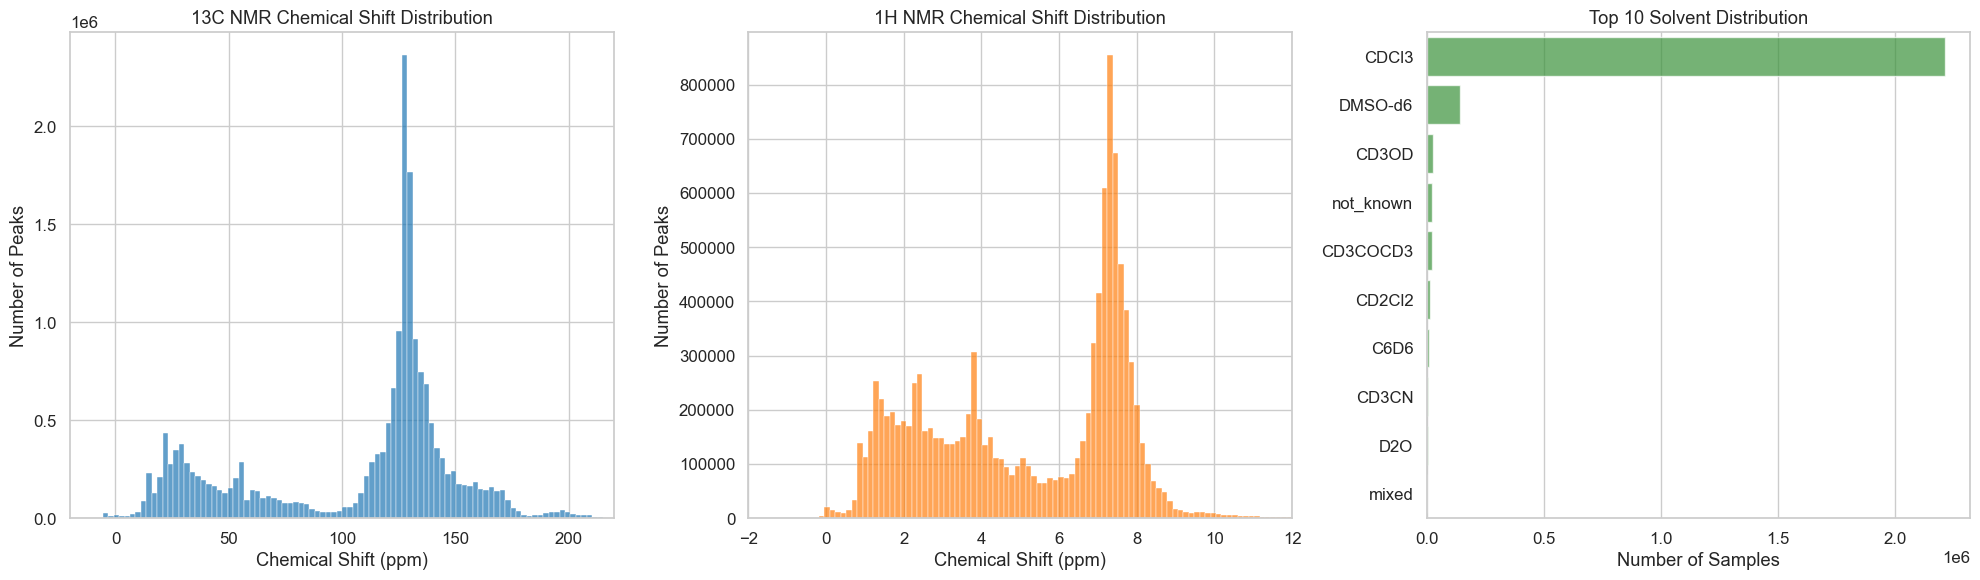

Total 13C peaks:    19427405
Total 1H peaks:     11152957
Unique solvents:    17
Most common solvent: CDCl3 (2211829 samples)


In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

c_shifts = []
h_shifts = []
solvents_c = []
solvents_h = []

for spectra in spectra_list:
    for peak in spectra['13C_NMR']['data']:
        try:
            c_shifts.append(float(peak['shift']))
        except (ValueError, TypeError):
            pass
    solvents_c.append(spectra['13C_NMR']['solvent'])

    for peak in spectra['1H_NMR']['data']:
        shift = peak['shift']
        try:
            if isinstance(shift, (tuple, list)):
                h_shifts.append((float(shift[0]) + float(shift[1])) / 2)
            else:
                h_shifts.append(float(shift))
        except (ValueError, TypeError):
            pass
    solvents_h.append(spectra['1H_NMR']['solvent'])


# ── 构建溶剂 DataFrame ──────────────────────────────────────────
all_solvents = solvents_c + solvents_h
solvent_counts = pd.Series(all_solvents).value_counts().head(10).reset_index()
solvent_counts.columns = ['Solvent', 'Count']

# ── 绘图 ────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. 13C 化学位移分布
sns.histplot(
    c_shifts,
    bins=100,
    binrange=(-20, 220),
    color='#1f77b4',
    edgecolor='white',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('13C NMR Chemical Shift Distribution')
axes[0].set_xlabel('Chemical Shift (ppm)')
axes[0].set_ylabel('Number of Peaks')
axes[0].set_xlim(-20, 220)

# 2. 1H 化学位移分布
sns.histplot(
    h_shifts,
    bins=100,
    binrange=(-2, 12),
    color='#ff7f0e',
    edgecolor='white',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('1H NMR Chemical Shift Distribution')
axes[1].set_xlabel('Chemical Shift (ppm)')
axes[1].set_ylabel('Number of Peaks')
axes[1].set_xlim(-2, 12)

# 3. 溶剂分布 Top10
sns.barplot(
    data=solvent_counts,
    y='Solvent',
    x='Count',
    color='#2ca02c',
    alpha=0.7,
    orient='h',
    ax=axes[2]
)
axes[2].set_title('Top 10 Solvent Distribution')
axes[2].set_xlabel('Number of Samples')
axes[2].set_ylabel('')

plt.tight_layout()
# save figure
plt.savefig('img/spectra_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


# ── 统计信息 ─────────────────────────────────────────────────────
unique_solvents = pd.Series(all_solvents).value_counts()
print(f"Total 13C peaks:    {len(c_shifts)}")
print(f"Total 1H peaks:     {len(h_shifts)}")
print(f"Unique solvents:    {len(unique_solvents)}")
print(f"Most common solvent: {unique_solvents.idxmax()} ({unique_solvents.max()} samples)")